使用`Diff3DElasticity.py`得到的数据

`grad_diffdata.csv`是采用Differentiable方法得到

`grad_finite.csv`是采用finite difference方法得到

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
from matplotlib import rcParams

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [17]:
grad_diffdata = np.loadtxt('grad_diffdata.csv', delimiter=',')
grad_finite = np.loadtxt('grad_finite.csv', delimiter=',')

error = np.abs(grad_diffdata - grad_finite)
# print('error:', error)
nmse = np.sum(error**2, axis=1) / np.sum(grad_diffdata**2 + grad_finite**2, axis=1)
# print('nmse:', nmse)

error: [[5.30413000e-10 3.33136000e-10 4.17745000e-10]
 [9.54719000e-10 4.51441000e-10 2.23123000e-10]
 [4.02683000e-10 1.37119000e-10 1.57800000e-12]
 ...
 [2.32501585e-03 5.63255468e-03 9.14075596e-04]
 [5.38304771e-03 9.26483291e-03 7.25459418e-03]
 [1.39782422e-03 5.16440422e-04 2.70002983e-03]]
nmse: [8.75119462e-02 3.24613948e-02 1.79456986e-02 9.73296040e-03
 1.70892163e+00 1.69025776e-15 1.44798610e+00 2.03258295e-02
 1.69368667e-02 4.25073928e-03 6.15218771e-03 4.72954609e-02
 4.96440885e-02 1.29212428e-01 1.95327362e-01 3.46820423e-01
 4.41854916e-01 1.84268316e-02 5.71969952e-04 5.04996891e-04
 4.72957129e-04 3.27306790e-03 7.53118805e-03 1.67362926e-02
 3.41341539e-02 5.95805922e-02 1.01372950e-01 3.16725586e-02
 3.63545286e-02 6.77151485e-02 9.84797468e-02 1.33550082e-01
 2.56245139e-01 4.51229821e-01 9.09114895e-01 1.47002706e+00
 1.76246478e+00 1.60160097e+00 2.28764776e-02 9.26340640e-02
 2.07651965e-01 4.00032253e-01 4.37055949e-01 7.44960160e-01
 1.23290152e+00 1.5854

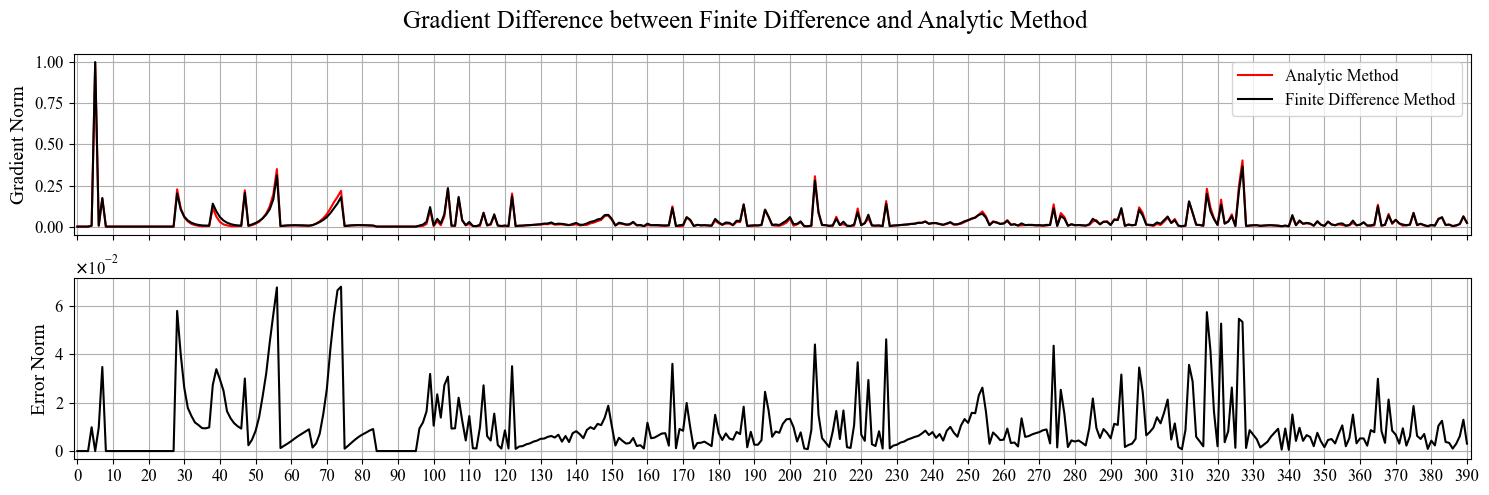

In [30]:
fig = plt.figure(figsize=(15, 5), dpi=100)
gs = GridSpec(2, 1, figure=fig)

fig.suptitle('Gradient Difference between Finite Difference and Analytic Method', fontsize=18)

ax_compare = fig.add_subplot(gs[0])
ax_compare.plot(np.linalg.norm(grad_diffdata, axis=1), label='Analytic Method', c='r')
ax_compare.plot(np.linalg.norm(grad_finite, axis=1), label='Finite Difference Method', c='k')
ax_compare.set_ylabel('Gradient Norm', fontsize=14)
ax_compare.legend(fontsize=12, loc='upper right')

ax_error = fig.add_subplot(gs[1])
ax_error.plot(np.linalg.norm(error, axis=1), c='k')
ax_error.set_ylabel('Error Norm', fontsize=14)

# ax_nmse = fig.add_subplot(gs[2])
# ax_nmse.plot(nmse, c='k')
# ax_nmse.set_ylabel('NMSE', fontsize=14)

axs = [ax_compare, ax_error]
for ax in axs:
    ax.set_xlim([-1, len(error)])
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.offsetText.set_fontsize(12)
    ax.yaxis.get_offset_text().set_fontsize(12)
    ax.grid('True', zorder=-1)
    ax.label_outer()

plt.tight_layout()
plt.show()

不用NSME来衡量误差，因为计算梯度对数值误差比较敏感，当梯度很小的时候，相对误差可能较大。但是梯度很小的部分，对模型的影响也小。